# Logistic Regression

Despite the name, logistic regression is a **classification** model. It fits a linear score and squashes it through the sigmoid function into a probability between 0 and 1, then thresholds that into a class.

**Topics covered in this notebook**

1. Intuition
2. Training on a dataset
3. Predicted probabilities
4. When to use it

**1. Intuition**

It computes a weighted sum of the features (like linear regression) and passes it through the **sigmoid** `1 / (1 + e^-z)`, which maps any number to a probability in (0, 1). A probability above 0.5 becomes class 1, below becomes class 0.

In [44]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for z in [-4, -1, 0, 1, 4]:
    print(f"z={z:2d} -> probability {sigmoid(z):.3f}")

z=-4 -> probability 0.018
z=-1 -> probability 0.269
z= 0 -> probability 0.500
z= 1 -> probability 0.731
z= 4 -> probability 0.982


**2. Training on a Dataset**

We classify tumours as malignant/benign using the built-in breast-cancer dataset. Because the model relies on weighted sums, we **scale** the features first so no single feature dominates.

In [45]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt 
import pandas as pd 

In [46]:
cancer = load_breast_cancer()          # Bunch, not a tuple
X, y = cancer.data, cancer.target

In [47]:
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)

In [56]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

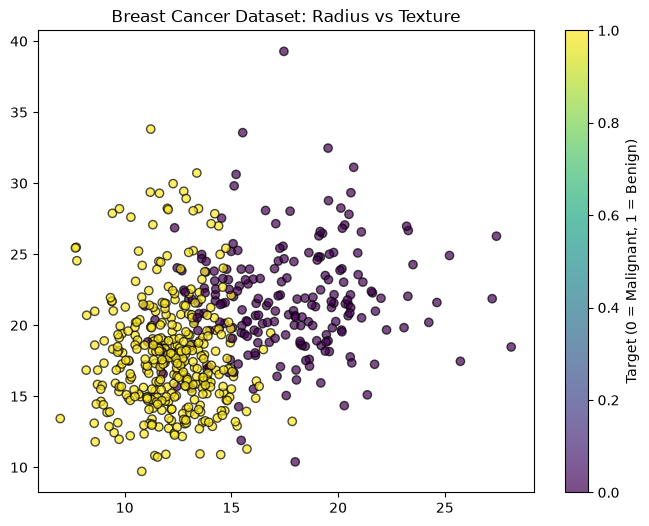

In [49]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)

plt.title('Breast Cancer Dataset: Radius vs Texture')
plt.colorbar(scatter, label='Target (0 = Malignant, 1 = Benign)')
plt.show()

In [50]:
X_train

array([[9.029e+00, 1.733e+01, 5.879e+01, ..., 1.750e-01, 4.228e-01,
        1.175e-01],
       [2.109e+01, 2.657e+01, 1.427e+02, ..., 2.903e-01, 4.098e-01,
        1.284e-01],
       [9.173e+00, 1.386e+01, 5.920e+01, ..., 5.087e-02, 3.282e-01,
        8.490e-02],
       ...,
       [1.429e+01, 1.682e+01, 9.030e+01, ..., 3.333e-02, 2.458e-01,
        6.120e-02],
       [1.398e+01, 1.962e+01, 9.112e+01, ..., 1.827e-01, 3.179e-01,
        1.055e-01],
       [1.218e+01, 2.052e+01, 7.722e+01, ..., 7.431e-02, 2.694e-01,
        6.878e-02]], shape=(455, 30))

In [51]:
# scale so features are comparable, then fit
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

In [52]:
X_train_s

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]], shape=(455, 30))

In [53]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)
preds = model.predict(X_test_s)

In [ ]:
# In this dataset class 0 = malignant, which is the clinically important case to
# catch, so we report precision/recall for the malignant class explicitly.
# (By default these metrics use pos_label=1, i.e. benign.)
print("accuracy             :", round(accuracy_score(y_test, preds), 3))
print("precision (malignant):", round(precision_score(y_test, preds, pos_label=0), 3))
print("recall    (malignant):", round(recall_score(y_test, preds, pos_label=0), 3))


**3. Predicted Probabilities**

Unlike a bare classifier, logistic regression gives **probabilities** via `predict_proba`. This lets you tune the decision threshold - e.g. flag anything above 0.3 when missing a positive is costly.

In [55]:
# each row: [P(class 0), P(class 1)]
probs = model.predict_proba(X_test_s[:5])
print("probabilities for the first 5 samples:")
print(probs.round(3))

probabilities for the first 5 samples:
[[0.114 0.886]
 [1.    0.   ]
 [0.997 0.003]
 [0.001 0.999]
 [0.    1.   ]]


**4. When to Use It**

- **Binary or multi-class classification** where you want a simple, interpretable model.
- You need **probabilities**, not just labels.
- Scale your features and increase `max_iter` if it fails to converge.
- Coefficients show each feature's direction and strength of influence.